# Latent Dirichlet Allocation

## Exploring Changing Sentiment in Climate Articles: 2013 to 2023

#### This notebook explores LDA concepts within the corpus.

#### Written by Rafael Alvarado(1) and Caroline Kranefuss(1).

(1) University of Virginia, 2026

### Imports

In [1]:
# General imports
import pandas as pd 
import numpy as np 
import os
import sys

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
sns.set_theme(style='white')
pio.renderers.default = 'iframe'

# Project-specific imports
import glob
from glob import glob
import nltk
nltk_resources = [
    'tokenizers/punkt', 
    'averaged_perceptron_tagger_eng',
    'corpora/stopwords', 
    'help/tagsets'
]

for resource in nltk_resources:
    try:
        nltk.data.find(resource)
    except LookupError:
        nltk.download(resource)
        
# Scikit Learn
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA, TruncatedSVD as SVD
from sklearn.feature_extraction import text
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation as LDA, NMF # Note importing of two topic modelers
        
# ----File Stitching----
# If not in repo home folder, cd back 
if os.path.basename(os.getcwd()) != "evolving_sentiment_climate":
    os.chdir('..')
# If a file is in /sources/, access it by telling the system to look at that path as well as current path
sys.path.append(os.path.join(os.getcwd(), 'sources'))
source_dir = "sources"
source_files_paths = glob(f"{source_dir}/*.xml")
# Same for csvs
sys.path.append(os.path.join(os.getcwd(), 'csvs'))
csvs_dir = "csvs"
csvs_files_paths = glob(f"{csvs_dir}/*.csv")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\student\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


### Setting OHCO

In [2]:
# Define OHCO
OHCO = ['year', 'mth_day', 'doc_id', 'sent_num', 'token_num']
bags = dict(
    SENTS = OHCO[:4],
    DOCS = OHCO[:3],
    MTH_DAY = OHCO[:2],
    YEAR = OHCO[:1]
)

bag = 'DOCS'

### Prepping Data

In [3]:
TOKENS = pd.read_csv('csvs/CORPUS/CORPUS.csv').set_index(OHCO)
TOKENS.head()

pos pos_group token_str  term_str
year mth_day doc_id sent_num token_num                                   
2018 12-18   0      0        0           DT        DT       The       the
                             1           JJ        JJ  southern  southern
                             2           NN        NN      cone      cone
                             3           IN        IN        of        of
                             4          NNP        NN     South     south

In [4]:
# Creating a DOCS table, filtering for nouns!
# Group by bag(doc_id), join strings, convert to df and format
DOCS = TOKENS[TOKENS.pos.str.match(r'.+')]\
    .groupby('doc_id').term_str\
    .apply(lambda x: ' '.join(map(str,x)))\
    .to_frame()\
    .rename(columns={'term_str':'doc_str'})

DOCS.head()

,doc_str
doc_id,
0,the southern cone of south america has been th...
1,anthropogenic ocean warming threatens the surv...
2,environmental changes eg global warming climat...
3,neither reducing the use of antibiotics nor di...
4,by 2050 the global human population will have ...


### Creating Vector Space

In [5]:
# Use english stopwords
my_stop_words = list(text.ENGLISH_STOP_WORDS)

# Built engine and model, build DFs!!
count_engine = CountVectorizer(max_df=.9, min_df=10, stop_words=my_stop_words)
count_model = count_engine.fit_transform(DOCS.doc_str)
TERMS = count_engine.get_feature_names_out()
VOCAB = pd.DataFrame(index=TERMS)
VOCAB.index.name = 'term_str'
DTM = pd.DataFrame(count_model.toarray(), index=DOCS.index, columns=TERMS)
DTM

,0001,001,002,004,005,007,01,02,025,03,...,years,yellow,yield,yielded,young,zero,zone,zones,µl,µm
doc_id,,,,,,,,,,,,,,,,,,,,,
0,0,1,0,0,0,0,0,0,0,1,...,4,0,0,0,0,0,1,0,0,0
1,6,0,0,0,22,0,1,0,0,0,...,2,0,0,0,0,0,0,0,0,0
2,0,0,0,0,2,0,0,0,0,0,...,2,1,1,0,0,0,0,0,0,0
3,2,2,0,0,7,3,4,2,2,0,...,0,0,0,0,0,0,0,0,2,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,17,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,6,0,1,0,0,1,0,0,0,0,...,6,0,0,0,1,1,15,35,0,0
88,5,0,1,0,6,0,0,1,0,0,...,8,0,1,0,0,1,0,6,0,0
89,2,0,0,0,0,1,1,0,0,0,...,22,0,0,0,1,2,0,0,0,0


A sparse matrix with many zeros

In [6]:
#settings 
n_topics = 20
max_iter = 100
n_top_terms = 9

TNAMES = [f"T{str(x).zfill(len(str(n_topics)))}" for x in range(n_topics)]

# Generate model
topic_engine = LDA(n_components=n_topics, max_iter=max_iter)

topic_model = topic_engine.fit_transform(count_model)

### Create THETA

In [7]:
THETA = pd.DataFrame(topic_model, index=DOCS.index, columns=TNAMES)
THETA.columns.name = 'topic_id'
THETA.sample(10).T.style.background_gradient(axis=None) # Use default color map
# Save
THETA.to_csv("csvs/LDA/THETA.csv")
THETA.head()

topic_id,T00,T01,T02,T03,T04,T05,T06,T07,T08,T09,T10,T11,T12,T13,T14,T15,T16,T17,T18,T19
doc_id,,,,,,,,,,,,,,,,,,,,
0,0.000035,0.000035,0.000035,0.014080,0.000035,0.000035,0.110812,0.000035,0.322909,0.000035,0.329589,0.000035,0.000035,0.097841,0.000035,0.000035,0.000035,0.124274,0.000035,0.000035
1,0.000017,0.000017,0.000017,0.000017,0.007650,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,0.879857,0.061205,0.000017,0.000017,0.000017,0.030259,0.009699,0.000017,0.011097
2,0.000033,0.020074,0.000033,0.000033,0.055967,0.091118,0.000033,0.000033,0.000033,0.000033,0.000033,0.439347,0.102997,0.000033,0.000033,0.000033,0.204139,0.000033,0.000033,0.085930
3,0.000029,0.082268,0.000029,0.000029,0.000029,0.000029,0.000029,0.000029,0.000029,0.000029,0.000029,0.023175,0.000029,0.000029,0.894058,0.000029,0.000029,0.000029,0.000029,0.000029
4,0.000058,0.381676,0.000058,0.092098,0.000058,0.000058,0.000058,0.000058,0.048785,0.000058,0.000058,0.000058,0.000058,0.000058,0.000058,0.000058,0.000058,0.085804,0.153200,0.237619


### Creating PHI

(Sort of a topic model)

In [8]:
PHI = pd.DataFrame(topic_engine.components_, columns=TERMS, index=TNAMES)
PHI.index.name = 'topic_id'
PHI.columns.name = 'term_str'
# Save
PHI.to_csv("csvs/LDA/PHI.csv")
PHI.T.sample(10).T.style.background_gradient(axis=None)


term_str,proportions,matrix,continue,existing,respect,identical,ambient,mentioned,implemented,75
topic_id,,,,,,,,,,
T00,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000
T01,4.963420,0.050000,0.050000,0.050000,1.510435,1.173323,0.050000,0.050000,0.050000,2.400612
T02,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,3.397564,0.050000,0.050000,2.426256
T03,0.050000,0.050000,0.050000,2.698124,6.574913,0.050000,0.050000,0.050000,0.050000,0.050000
T04,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.930726,0.050000,0.050000,0.050000
T05,6.670549,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,3.895773,0.050000,0.050000
T06,0.050000,5.226419,2.326819,1.439908,4.589863,1.421743,0.050000,4.340376,1.570482,2.501657
T07,0.050000,17.509420,0.050000,0.050000,0.050000,0.050000,1.050000,1.489502,0.050000,0.050000
T08,0.050000,9.443149,22.182587,13.378195,17.893290,4.428169,0.050000,8.103660,19.030205,8.498088


### Creating TOPICS, Obtaining Top Terms, Sorting

In [9]:
# Stacking PHi, grouping by topic id and joining, only keeping the number of top terms chosen
TOPICS = PHI.stack().groupby('topic_id')\
    .apply(lambda x: ' '.join(x.sort_values(ascending=False).head(n_top_terms).reset_index().term_str))\
    .to_frame('top_terms')
# Save
TOPICS.to_csv("csvs/LDA/TOPICS.csv")
TOPICS

,top_terms
topic_id,
T00,tool determination extends impacting cut lowla...
T01,soil plant water plants root area growth conte...
T02,species expression gene temperature warming pl...
T03,carbon land forest urban storage area trees tr...
T04,size group distance effect shape effects depth...
T05,species native areas urban sites habitat area ...
T06,species vegetation south range eastern new coa...
T07,drought model values prediction value vegetati...
T08,species diversity host samples sequences taxa ...


In [10]:
# Sort by Doc Weight using the sum to calculate
TOPICS['doc_weight_sum'] = THETA.sum()
TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()
TOPICS.sort_values('doc_weight_sum', ascending=False).style.background_gradient(cmap='YlGnBu', axis=0)

C:\Users\student\AppData\Local\Temp\ipykernel_35716\3231892464.py:3: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()
C:\Users\student\AppData\Local\Temp\ipykernel_35716\3231892464.py:3: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()


,top_terms,doc_weight_sum,term_freq
topic_id,,,
T08,species diversity host samples sequences taxa phylogenetic sequence community,11.128685,0.124567
T01,soil plant water plants root area growth content conditions,8.057903,0.074194
T19,control density temperature time mean model low response precipitation,7.696873,0.075109
T18,city technology development use research model information management network,6.545312,0.112242
T11,coral rates corals temperature larvae microbial effects community reef,5.741740,0.068368
T06,species vegetation south range eastern new coastal coast area,5.338497,0.054724
T09,species prey reefs individuals sea 2015 coral sites food,5.076430,0.046389
T17,predicted model future models species habitat areas suitable distribution,4.953156,0.050050
T16,populations population dna age number species methods sample samples,4.925809,0.051932


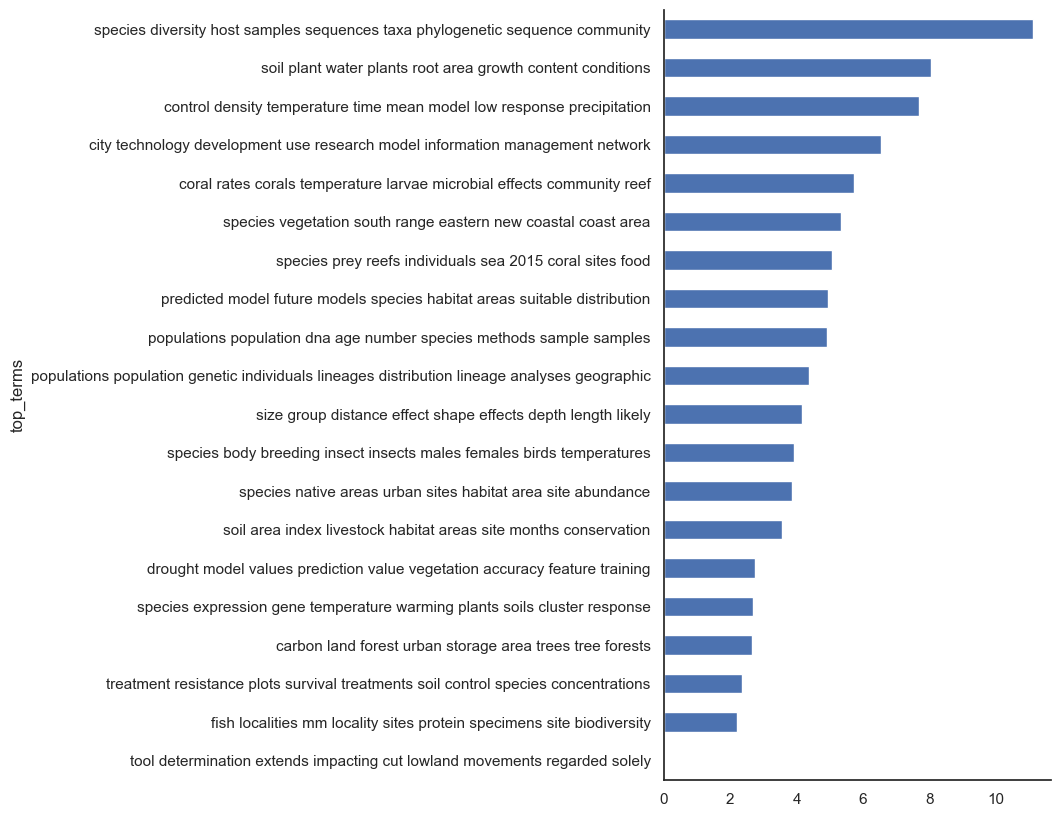

In [11]:
# Again, sort values and plot it for another visualization
TOPICS.sort_values('doc_weight_sum', ascending=True).plot.barh(y='doc_weight_sum', x='top_terms', figsize=(5, n_topics/2), legend=False)
sns.despine()
plt.show()

Topic 11 is weighted most heavily and is comprised of the terms "populations species population genetic habitat range distribution predicted suitable." This makes sense - populations of species and habitat ranges are deeply impacted by climate change. I would not find it hard to believe that it dominates all years; despite prior findings that 2023 introduces more technological findings, climate change still very much impacts biological phenomena, especially given the way that data centers and AI is consuming water at an unprecedented rate, hurting species around the globe.

I'm particularly partial to Topic 4, "model areas models area precipitation temperature potential values variables", because they connect directly to my research! I am building a CNN to model robust and consistent signals of climate change in net-zero scenarios, looking at variables like precipipation and temperature to comprise these signals. That aside, this grouping makes sense and is an unsurprising second candidate for the list of topics. Climate change directly impacts rain and heat (and cold!) - changing those variables is how it devastates the planet, no matter which area connected to climate change one is studying.

Topic 13 is weighted least heavily, holding the terms "geographic transport modern scaled living fossil drift ranges range". I am suprised that range appears in both Topic 11 and Topic 13 - perhaps it means different things in different topics? Range has quite a range of meanings (sorry for the second pun) and maybe the Topic 11 discusses habitat ranges and population distributions and Topic 13 means the range that different scales hold.

To explore a topic in the middle, Topic 3 describes "populations population dna age number sample disease individuals adult". This is pretty interesting. Changes in climate can certainly impact disease and even manipulate individuals' DNA, but I wasn't expecting this to be its own topic, as it seems like a niche topic that I didn't see appearing in many of the articles' abstracts, but I suppose I missed or overloooked something - the benefit of LDA!

### Exploring by Year

In [12]:
# Read in LIB for metadata
LIB = pd.read_csv('csvs/LIB/LIB.csv').set_index('doc_id')

# Join the two
THETA_YR = pd.merge(LIB, THETA, on=LIB.index)

THETA_YR.drop(columns=[ 'doc_1st_author', 'sent_str', 'doc_title', 'num_words', 'num_chars'], inplace=True)

THETA_YR = THETA_YR.rename(columns={'key_0': 'doc_id'})

# Settings
THETA_YR.set_index(['doc_id', 'year'], inplace=True)

In [13]:
# Group by year
TOPIC_YR = THETA_YR.groupby(THETA_YR.index.get_level_values('year')).mean()
# Transpose, settings
TOPIC_YR.T.style.background_gradient(axis=0, cmap="YlGnBu")

year,2013,2018,2023
T00,0.000032,0.000030,0.000029
T01,0.087085,0.080057,0.095358
T02,0.006340,0.046514,0.023043
T03,0.009118,0.040681,0.026607
T04,0.058017,0.014325,0.069813
T05,0.038875,0.038354,0.047536
T06,0.020245,0.088858,0.045576
T07,0.057364,0.005121,0.041327
T08,0.097293,0.116616,0.136827
T09,0.003367,0.047110,0.088452


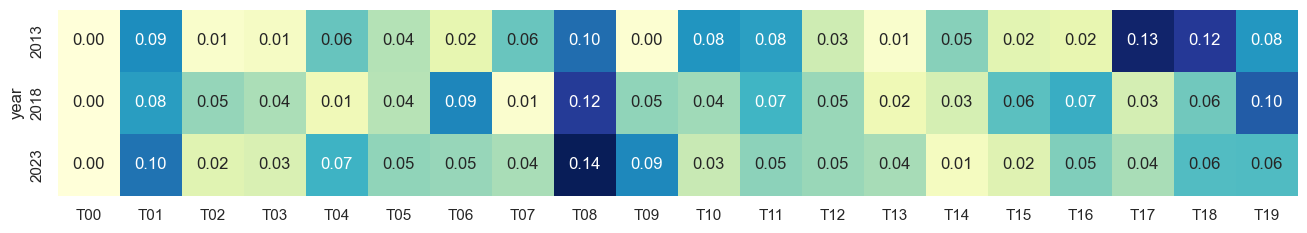

In [14]:
# Set fig size so that figure can hold annotations
fig = plt.subplots(figsize=(16, 16))
# Round annotations so they fit better, make the cells square
sns.heatmap(TOPIC_YR, cmap="YlGnBu", cbar=None, annot=True, fmt=".2f", square=True)
plt.show()

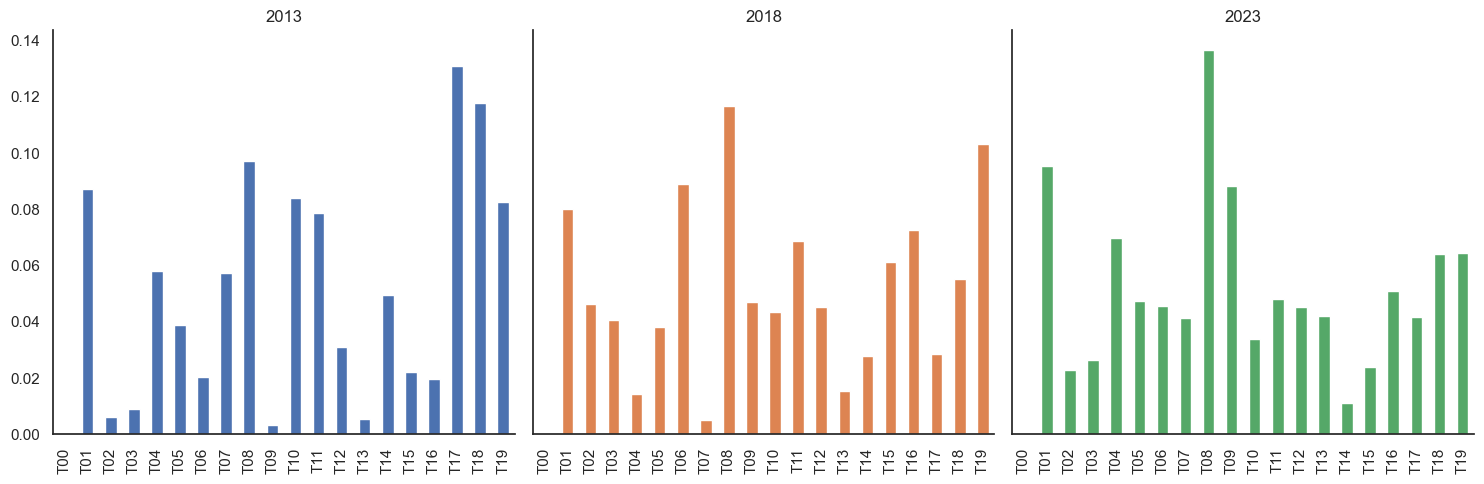

In [15]:
TOPIC_YR.T.plot.bar(subplots=True, figsize=(15,5), legend=False, sharey=True, layout=(1,3)) # Layout param from claude, was using fig, ax = sublpots(1,3)
sns.despine()
plt.tight_layout()
plt.show()

### Analysis

Topic 11 is weighted most heavily and is comprised of the terms "populations species population genetic habitat range distribution predicted suitable." This makes sense - populations of species and habitat ranges are deeply impacted by climate change. I would not find it hard to believe that it dominates all years; despite prior findings that 2023 introduces more technological findings, climate change still very much impacts biological phenomena, especially given the way that data centers and AI is consuming water at an unprecedented rate, hurting species around the globe.

I'm particularly partial to Topic 4, "model areas models area precipitation temperature potential values variables", because they connect directly to my research! I am building a CNN to model robust and consistent signals of climate change in net-zero scenarios, looking at variables like precipipation and temperature to comprise these signals. That aside, this grouping makes sense and is an unsurprising second candidate for the list of topics. Climate change directly impacts rain and heat (and cold!) - changing those variables is how it devastates the planet, no matter which area connected to climate change one is studying.

Topic 13 is weighted least heavily, holding the terms "geographic transport modern scaled living fossil drift ranges range". I am suprised that range appears in both Topic 11 and Topic 13 - perhaps it means different things in different topics? Range has quite a range of meanings (sorry for the second pun) and maybe the Topic 11 discusses habitat ranges and population distributions and Topic 13 means the range that different scales hold.

To explore a topic in the middle, Topic 3 describes "populations population dna age number sample disease individuals adult". This is pretty interesting. Changes in climate can certainly impact disease and even manipulate individuals' DNA, but I wasn't expecting this to be its own topic, as it seems like a niche topic that I didn't see appearing in many of the articles' abstracts, but I suppose I missed or overloooked something - the benefit of LDA!

Topics 3 to 7 play a heavy role in each year (T03 populations population dna age number sample; T04 model areas models area precipitation temperature; 
T05	temperature rates coral effects treatment larvae; T06 coral density group individuals species corals; T07 plant plants stress water growth bacteria)

Topic 11 decreases in importance as each year progresses (populations species population genetic habitat range distribution predicted suitable) - perhaps adding credence to my technology-growth theory!

Topics 16 and 17 increase in importance as the years progress (T16 species sites mm site native time biodiversity specimens number; T17 species diversity samples sequences community phylogenetic taxa communities sample), which perhaps (and this could be  stretch) refers to the growth in genetics-based research as technological capabilities have evolved the past decade (see the genetics program here at SDS!)

2013 seems to have the highest variation, with some very high highs and lots of low lows, while 2018 and 2023 are more balanced. 

### Applying PCA

**Goals:**

Apply PCA to the THETA table and plot the topics in the space opened by the first two components.

Size the points based on the mean document weight of each topic (using the THETA table).

Color the points basd on a metadata feature from the LIB table.

In [16]:
THETA_YR.head()

,,T00,T01,T02,T03,T04,T05,T06,T07,T08,T09,T10,T11,T12,T13,T14,T15,T16,T17,T18,T19
doc_id,year,,,,,,,,,,,,,,,,,,,,
9,2013,0.000035,0.000035,0.000035,0.014080,0.000035,0.000035,0.110812,0.000035,0.322909,0.000035,0.329589,0.000035,0.000035,0.097841,0.000035,0.000035,0.000035,0.124274,0.000035,0.000035
60,2013,0.000017,0.000017,0.000017,0.000017,0.007650,0.000017,0.000017,0.000017,0.000017,0.000017,0.000017,0.879857,0.061205,0.000017,0.000017,0.000017,0.030259,0.009699,0.000017,0.011097
69,2013,0.000033,0.020074,0.000033,0.000033,0.055967,0.091118,0.000033,0.000033,0.000033,0.000033,0.000033,0.439347,0.102997,0.000033,0.000033,0.000033,0.204139,0.000033,0.000033,0.085930
42,2013,0.000029,0.082268,0.000029,0.000029,0.000029,0.000029,0.000029,0.000029,0.000029,0.000029,0.000029,0.023175,0.000029,0.000029,0.894058,0.000029,0.000029,0.000029,0.000029,0.000029
13,2013,0.000058,0.381676,0.000058,0.092098,0.000058,0.000058,0.000058,0.000058,0.048785,0.000058,0.000058,0.000058,0.000058,0.000058,0.000058,0.000058,0.000058,0.085804,0.153200,0.237619


In [17]:
# Use 3 components - cannot use more than the number of documents
pca_engine = PCA(n_components=3)

# Apply it to the TFIDF table to create a document count matrix
DCM_THETA = pd.DataFrame(pca_engine.fit_transform(THETA_YR), index=THETA_YR.index)

DCM_THETA.columns = ["PC{}".format(i) for i in DCM_THETA.columns]

DCM_THETA

,,PC0,PC1,PC2
doc_id,year,,,
9,2013,-0.253888,0.182902,-0.109377
60,2013,0.185758,-0.247867,-0.162432
69,2013,0.093756,-0.164059,-0.068412
42,2013,0.087535,-0.035066,0.023523
13,2013,0.311382,0.116134,0.097447
...,...,...,...,...
23,2023,-0.056034,-0.102741,0.055766
65,2023,-0.035391,-0.086620,0.192758
67,2023,-0.099983,-0.043603,0.031327


In [18]:
# Make a components table that essentially documents the explained variance of each term
# I.e., how much each term is part of any given component
# This will help in defining the components' meanings 
COMPS_THETA = pd.DataFrame(pca_engine.components_.T * np.sqrt(pca_engine.explained_variance_))
# Formatting and settings (columns, index, transpose for easy viewing)
#COMPS_THETA.columns = ["PC{}".format(i) for i in THETA_YR.columns]
COMPS_THETA.index.name = 'term_str'
COMPS_THETA.T

term_str,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,4.252900e-07,0.163625,-0.001610,0.008129,-0.004002,-0.010078,-0.041457,-0.005741,-0.090692,-0.000002,-0.044105,0.047572,-0.013269,-0.008165,0.006173,-0.008945,-0.019311,-0.020374,-0.000289,0.042540
1,5.907206e-07,0.093224,-0.005548,-0.005233,-0.027864,-0.010232,-0.002444,-0.006961,0.121963,-0.113206,0.027923,-0.044049,-0.006725,-0.002244,-0.003525,0.014108,0.001765,-0.002592,-0.000937,-0.027426
2,-3.436548e-06,-0.027177,-0.001158,0.024036,-0.006007,0.007108,-0.008382,0.033909,-0.056089,-0.079841,-0.028308,-0.040785,0.000772,0.003890,0.004450,-0.005520,0.002326,0.019776,0.152157,0.004846


In [19]:
# A function to visualize the principal components
# Inputs: The DCM df, PCs a and b
def vis_pcs(DCM, a, b):
    return px.scatter(DCM, f"PC{a}", f"PC{b}",
                      color=DCM.index.get_level_values('year').astype(str),
                      hover_name=DCM.index.get_level_values('doc_id').astype(str),
                      marginal_x='box', height=800)

# Another function for visualization
# Inputs: The COMPS df, PCs and b
def vis_loadings(COMPS, a, b):
    return px.scatter(COMPS.T, f"PC{a}", f"PC{b}", 
                      text=COMPS.T.index,
                      hover_name=COMPS.index,
                      marginal_x='box', 
                      height=800)

In [28]:
vis_pcs(DCM_THETA, 0, 1)